The purpose of this notebook is to generate some clean equilbrium scaling plots
Potentially use cluster if its useful.



NEEDS to be cleaned up!


In [7]:
import sys
import os
sys.path.append("../../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter
from collections import Counter
from tqdm import tqdm

##Personal Imports##

from numpy import pi, cos, sin, exp, log, sqrt, array
#import equilibrium_critical_correlations as ecc
from equilibrium_critical_correlations import P_n, sigma_general, P_n_correlations, Dn

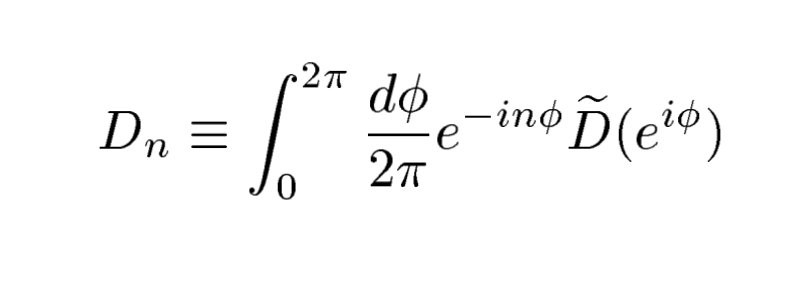

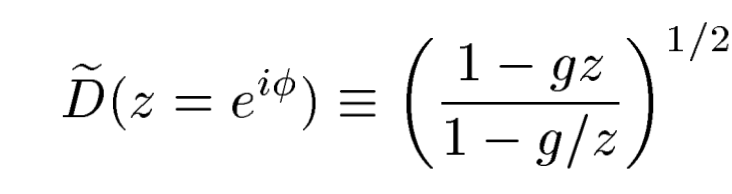

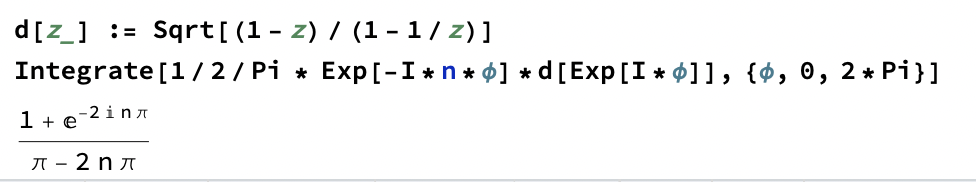

In [ ]:
###correlator
def correlator_data(n,rmin,rmax):
    Pn = P_n(n)

    r_points = np.arange(rmin,rmax)
    ##Definition of connected correlator in a translationally invariant system
    data = array([P_n_correlations(n,r)-Pn**2 for r in tqdm(r_points)])
    return [data,r_points]

def correlator_scaled(n,rmin,rmax):
    r_points = np.arange(rmin,rmax)
    Pn = P_n(n)
    ##Definition of connected correlator in a translationally invariant system
    data = array([(P_n_correlations(n,r)-Pn**2)/Pn**2 for r in tqdm(r_points)])
    return [data,r_points]

def correlator_unconnected(n,rmin,rmax):
    r_points = np.arange(rmin,rmax)
   # Pn = P_n(n)
    ##Definition of connected correlator in a translationally invariant system
    data = array([(P_n_correlations(n,r)) for r in tqdm(r_points)])
    return [data,r_points]


folder_name = "connected_correlations"

# Create the folder if it doesn't exist
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
for n in (range(1,12)):
    rmin = 50
    rmax = 150

    # get only the data part
    data, _ = correlator_data(n, rmin, rmax)

    # save it
    np.save(f"{folder_name}/correlator_data{n}_r{rmin}-{rmax}.npy", data)
    # or text:
    # np.savetxt(f"data/correlator_n{n}_r{rmin}-{rmax}.txt", data)
    print(f"n = {n} completed!")


  0%|          | 0/100 [00:00<?, ?it/s]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 100/100 [00:00<00:00, 757.82it/s]


n = 1 completed!


100%|██████████| 100/100 [00:00<00:00, 265.31it/s]


n = 2 completed!


100%|██████████| 100/100 [00:01<00:00, 63.08it/s]


n = 3 completed!


100%|██████████| 100/100 [00:06<00:00, 15.76it/s]


n = 4 completed!


 49%|████▉     | 49/100 [00:07<00:11,  4.32it/s]

KeyboardInterrupt: 

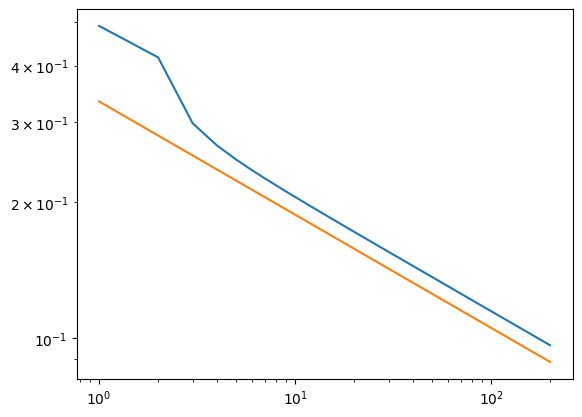

In [12]:
X= np.array([x for x in range(1,200)])

plt.loglog(X,[sigma_general([0,1,2,x,x+1,x+2]) for x in X])
plt.loglog(X,1/3*X**(-1/4)/X[0]**(-1/4))

In [24]:
G2r= array([sigma_general([0,i]) for i in X])
G2r1=array([sigma_general([0,i+1]) for i in X])
G2r2=array([sigma_general([0,i+2]) for i in X])
G21 = sigma_general([0,1])**2

G4 = array([sigma_general([0,1,1+i,2+i]) for i in X])

P2P2 = array([P_n_correlations(2,i) -P_n(2)**2 for i in X])
P1P1 = array([sigma_general([0,i])/4 for i in X])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Text(0, 0.5, 'Expectation')

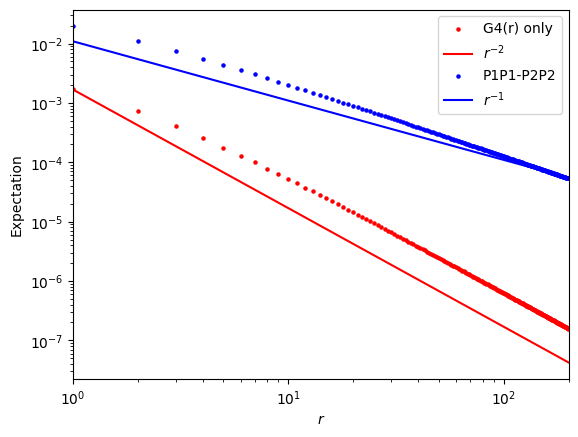

In [26]:
from matplotlib.pyplot import xlim, ylim, loglog, scatter,legend,xlabel,ylabel

#plot(xi,P2P2,label="Full P2P2 Correlation")
#plt.scatter(xi,(G2r+G2r1*2+G2r2)/16,s=4)

#scatter(xi,(G2r+G2r1*2+G2r2)/16,s=10,color="black",label="2 Bodied Terms only")
scatter(X,(G4-G21)/16,s=5,label="G4(r) only",color="red")
plot(X,abs(G4/16-G21/16)[0]*X**(-2.),label=r"$r^{-2}$",color="red")

#plot(xi,P1P1,label="P1P1 correlation")
scatter(X,abs(P1P1-P2P2),label=r"P1P1-P2P2",s=5,color="blue")
plot(X,abs(P1P1-P2P2)[1]*X**(-1.),label=r"$r^{-1}$",color="blue")

#plt.plot(xi,(G4-G21)/16)
xlim(1,200)
#ylim(.025,.2)
loglog()
legend()
xlabel(r"$r$")
ylabel(r"Expectation")